# New Jersey Home Affordability Analysis: 2015-2025 Period

**Analysis of demographic patterns, gentrification effects, and community degradation across New Jersey municipalities over the past decade**

This notebook analyzes:
- Housing price trends from 2015-2025 (10-year period)
- Demographic shifts and affordability patterns
- Gentrification indicators with specific town examples
- Communities experiencing degradation vs improvement
- Regional contrasts and county-level patterns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import pgeocode
from pathlib import Path
import sys

# Use pgeocode instead of uszipcode
nomi = pgeocode.Nominatim('us')

# Example usage:
# Get info for a zipcode
zipcode_info = nomi.query_postal_code("10001")
print(zipcode_info)

# Or if you need batch lookups:
zipcodes = ["10001", "90210", "60601"]
results = [nomi.query_postal_code(z) for z in zipcodes]

# Consistent color palette
PALETTE = {
    'Degrading (Economic Distress)': '#d62728',     # Red
    'Middle Class Stable': '#ff7f0e',                # Orange
    'Gentrifying (High Price Growth)': '#2ca02c'     # Green
}
COLORS_LIST = ['#d62728', '#ff7f0e', '#2ca02c']

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


def find_project_root(start: Path) -> Path:
    for path in [start.resolve(), *start.resolve().parents]:
        if (path / "config.py").exists():
            return path
    raise FileNotFoundError("Could not locate project root containing config.py")


def connect_duckdb() -> duckdb.DuckDBPyConnection:
    project_root = find_project_root(Path.cwd())

    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))

    from config import DB_PATH

    db_path = Path(DB_PATH)
    if not db_path.exists():
        raise FileNotFoundError(f"DuckDB database not found at: {db_path}")

    return duckdb.connect(str(db_path), read_only=True)


# Connect to database
conn = connect_duckdb()

postal_code          10001
country_code            US
place_name        New York
state_name        New York
state_code              NY
county_name       New York
county_code           61.0
community_name         NaN
community_code         NaN
latitude           40.7484
longitude         -73.9967
accuracy               4.0
Name: 0, dtype: object
Connected to: /Users/caiotormin/torm/nj_pipeline/data/db/nj_pipeline.duckdb


## 1. Load Affordability Data (Last 10 Years: 2015-2025)

In [2]:
# Calculate affordability metrics by zip code (2015-2025)
affordability = conn.execute("""
    WITH latest_zhvi AS (
        SELECT 
            zip_code,
            county,
            date,
            zhvi_usd,
            ROW_NUMBER() OVER (PARTITION BY zip_code ORDER BY date DESC) as rn
        FROM zillow_home_values
        WHERE zhvi_usd IS NOT NULL
    ),
    baseline_zhvi AS (
        SELECT 
            zip_code,
            zhvi_usd as zhvi_baseline,
            date as baseline_date
        FROM zillow_home_values
        WHERE zhvi_usd IS NOT NULL
            AND date >= '2015-01-01'
            AND date <= '2015-12-31'
        QUALIFY ROW_NUMBER() OVER (PARTITION BY zip_code ORDER BY date ASC) = 1
    )
    SELECT 
        l.zip_code,
        l.county,
        l.zhvi_usd as current_home_value,
        b.zhvi_baseline as baseline_home_value,
        b.baseline_date,
        l.date as latest_date,
        c.income_median_hh,
        c.pop_total,
        c.poverty_rate,
        c.homeownership_rate,
        c.gross_rent_median,
        c.rent_burden_severe_pct,
        c.diversity_index,
        c.pct_bachelors_plus,
        c.acs_year,
        CASE WHEN c.income_median_hh > 0 
             THEN l.zhvi_usd / c.income_median_hh 
             ELSE NULL END as price_to_income_ratio,
        ((l.zhvi_usd - b.zhvi_baseline) / b.zhvi_baseline * 100) as price_change_pct,
        (l.zhvi_usd - b.zhvi_baseline) as price_change_usd
    FROM latest_zhvi l
    LEFT JOIN baseline_zhvi b ON l.zip_code = b.zip_code
    LEFT JOIN census_acs c ON l.zip_code = c.zcta AND c.geo_type = 'zcta'
    WHERE l.rn = 1
        AND l.county IS NOT NULL
        AND b.zhvi_baseline IS NOT NULL
    ORDER BY l.county, l.zip_code
""").df()

print(f"\nAffordability data: {len(affordability)} zip codes")
print(f"\nAffordability Metrics Summary (2015-2025):")
print(affordability[['price_to_income_ratio', 'price_change_pct', 'poverty_rate', 'rent_burden_severe_pct']].describe())


Affordability data: 6481 zip codes

Affordability Metrics Summary (2015-2025):
       price_to_income_ratio  price_change_pct  poverty_rate  \
count            6466.000000       6481.000000   6480.000000   
mean                9.900898        120.171220      8.122958   
std                 7.519340         62.116613      7.165916   
min                 2.584108         22.021046      0.000000   
25%                 6.484778         75.575642      3.620000   
50%                 8.051789        111.247184      5.990000   
75%                10.522470        146.237501      9.760000   
max               131.150203        531.902420     53.650000   

       rent_burden_severe_pct  
count             6437.000000  
mean                24.192175  
std                 11.430801  
min                  0.000000  
25%                 17.330000  
50%                 23.910000  
75%                 30.500000  
max                100.000000  


## 2. Gentrification Analysis

In [3]:
# Identify gentrification indicators
gentrification = affordability.copy()

# Calculate gentrification score (adjusted for 10-year period)
gentrification['gent_score'] = 0

# High price growth (adjusted thresholds for 10 years)
gentrification.loc[gentrification['price_change_pct'] > 50, 'gent_score'] += 2
gentrification.loc[(gentrification['price_change_pct'] > 35) & (gentrification['price_change_pct'] <= 50), 'gent_score'] += 1

# High education levels (indicator of demographic shift)
gentrification.loc[gentrification['pct_bachelors_plus'] > 50, 'gent_score'] += 1

# Low poverty (gentrified areas typically have lower poverty)
gentrification.loc[gentrification['poverty_rate'] < 10, 'gent_score'] += 1

# High price-to-income (decreased affordability)
gentrification.loc[gentrification['price_to_income_ratio'] > 6, 'gent_score'] += 1

# Classify areas
gentrification['gentrification_status'] = 'Stable'
gentrification.loc[gentrification['gent_score'] >= 4, 'gentrification_status'] = 'High Gentrification'
gentrification.loc[(gentrification['gent_score'] >= 2) & (gentrification['gent_score'] < 4), 'gentrification_status'] = 'Moderate Gentrification'

# Summary
gent_summary = gentrification.groupby('gentrification_status').agg({
    'zip_code': 'count',
    'price_change_pct': 'mean',
    'price_to_income_ratio': 'mean',
    'pct_bachelors_plus': 'mean',
    'poverty_rate': 'mean'
}).round(2)

print("\n" + "="*70)
print("GENTRIFICATION ANALYSIS SUMMARY (2015-2025)")
print("="*70)
print(gent_summary)
print("="*70)

# Show specific examples
print("\n📍 HIGH GENTRIFICATION EXAMPLES:")
high_gent = gentrification[gentrification['gentrification_status'] == 'High Gentrification'].sort_values('price_change_pct', ascending=False)
for idx, row in high_gent.head(10).iterrows():
    print(f"  • ZIP {row['zip_code']} ({row['county']}): +{row['price_change_pct']:.1f}% | ${row['current_home_value']:,.0f} | Income ratio: {row['price_to_income_ratio']:.1f}x")

print("\n📍 STABLE COMMUNITIES:")
stable = gentrification[gentrification['gentrification_status'] == 'Stable'].sort_values('price_change_pct')
for idx, row in stable.head(5).iterrows():
    print(f"  • ZIP {row['zip_code']} ({row['county']}): {row['price_change_pct']:+.1f}% | ${row['current_home_value']:,.0f}")


GENTRIFICATION ANALYSIS SUMMARY (2015-2025)
                         zip_code  price_change_pct  price_to_income_ratio  \
gentrification_status                                                        
High Gentrification          4183            116.28                  10.24   
Moderate Gentrification      2256            129.08                   9.33   
Stable                         42             29.04                   6.11   

                         pct_bachelors_plus  poverty_rate  
gentrification_status                                      
High Gentrification                    48.8          5.02  
Moderate Gentrification                26.5         13.61  
Stable                                 12.9         22.27  

📍 HIGH GENTRIFICATION EXAMPLES:
  • ZIP 07711 (Monmouth County): +531.9% | $4,520,492 | Income ratio: 35.9x
  • ZIP 07711 (Monmouth County): +531.9% | $4,520,492 | Income ratio: 34.7x
  • ZIP 07711 (Monmouth County): +531.9% | $4,520,492 | Income ratio: 35.1x
  •

## 3. Community Degradation Analysis

In [4]:
# Identify degrading communities
degradation = affordability.copy()

# Calculate degradation score (adjusted for 10-year period)
degradation['degrad_score'] = 0

# Low/negative price growth (adjusted for 10 years)
degradation.loc[degradation['price_change_pct'] < 15, 'degrad_score'] += 2
degradation.loc[(degradation['price_change_pct'] >= 15) & (degradation['price_change_pct'] < 25), 'degrad_score'] += 1

# High poverty
degradation.loc[degradation['poverty_rate'] > 20, 'degrad_score'] += 2
degradation.loc[(degradation['poverty_rate'] > 15) & (degradation['poverty_rate'] <= 20), 'degrad_score'] += 1

# Severe rent burden
degradation.loc[degradation['rent_burden_severe_pct'] > 25, 'degrad_score'] += 1

# Low homeownership
degradation.loc[degradation['homeownership_rate'] < 40, 'degrad_score'] += 1

# Classify
degradation['degradation_status'] = 'Stable/Growing'
degradation.loc[degradation['degrad_score'] >= 4, 'degradation_status'] = 'High Degradation'
degradation.loc[(degradation['degrad_score'] >= 2) & (degradation['degrad_score'] < 4), 'degradation_status'] = 'Moderate Degradation'

# Summary
degrad_summary = degradation.groupby('degradation_status').agg({
    'zip_code': 'count',
    'price_change_pct': 'mean',
    'poverty_rate': 'mean',
    'rent_burden_severe_pct': 'mean',
    'homeownership_rate': 'mean'
}).round(2)

print("\n" + "="*70)
print("COMMUNITY DEGRADATION ANALYSIS (2015-2025)")
print("="*70)
print(degrad_summary)
print("="*70)

# Show specific examples
print("\n📍 HIGH DEGRADATION EXAMPLES:")
high_degrad = degradation[degradation['degradation_status'] == 'High Degradation'].sort_values('poverty_rate', ascending=False)
for idx, row in high_degrad.head(10).iterrows():
    print(f"  • ZIP {row['zip_code']} ({row['county']}): {row['poverty_rate']:.1f}% poverty | {row['price_change_pct']:+.1f}% price change | {row['homeownership_rate']:.1f}% homeownership")

print("\n📍 MODERATE DEGRADATION EXAMPLES:")
mod_degrad = degradation[degradation['degradation_status'] == 'Moderate Degradation'].sort_values('poverty_rate', ascending=False)
for idx, row in mod_degrad.head(5).iterrows():
    print(f"  • ZIP {row['zip_code']} ({row['county']}): {row['poverty_rate']:.1f}% poverty | {row['price_change_pct']:+.1f}% price change")


COMMUNITY DEGRADATION ANALYSIS (2015-2025)
                      zip_code  price_change_pct  poverty_rate  \
degradation_status                                               
High Degradation           312            189.88         29.60   
Moderate Degradation       516            149.11         19.54   
Stable/Growing            5653            113.68          5.90   

                      rent_burden_severe_pct  homeownership_rate  
degradation_status                                                
High Degradation                       32.85               25.78  
Moderate Degradation                   31.11               48.43  
Stable/Growing                         23.08               76.96  

📍 HIGH DEGRADATION EXAMPLES:
  • ZIP 08102 (Camden County): 53.6% poverty | +64.0% price change | 22.4% homeownership
  • ZIP 08102 (Camden County): 53.0% poverty | +64.0% price change | 20.0% homeownership
  • ZIP 08102 (Camden County): 50.5% poverty | +64.0% price change | 25.6% homeown

## 4. Regional Contrasts: Combined Analysis

In [5]:
# Compare gentrifying vs degrading communities
comparison = affordability.copy()

# Merge both scores
comparison = comparison.merge(
    gentrification[['zip_code', 'gent_score', 'gentrification_status']],
    on='zip_code',
    how='left'
)
comparison = comparison.merge(
    degradation[['zip_code', 'degrad_score', 'degradation_status']],
    on='zip_code',
    how='left'
)

# Create overall classification
comparison['community_type'] = 'Middle Class Stable'
comparison.loc[comparison['gentrification_status'] == 'High Gentrification', 'community_type'] = 'Gentrifying (High Price Growth)'
comparison.loc[comparison['degradation_status'] == 'High Degradation', 'community_type'] = 'Degrading (Economic Distress)'

# Summary by type
type_summary = comparison.groupby('community_type').agg({
    'zip_code': 'count',
    'current_home_value': 'median',
    'price_change_pct': 'mean',
    'price_to_income_ratio': 'mean',
    'poverty_rate': 'mean',
    'pct_bachelors_plus': 'mean',
    'income_median_hh': 'median'
}).round(2)

type_summary.columns = ['Count', 'Median Home Value', 'Avg Price Change %', 
                        'Avg Price/Income', 'Avg Poverty %', 'Avg Bach+ %', 'Median Income']

print("\n" + "="*90)
print("REGIONAL CONTRASTS: COMMUNITY TYPE COMPARISON (2015-2025)")
print("="*90)
print(type_summary)
print("="*90)

# Show county-level patterns
print("\n📊 GENTRIFYING COMMUNITIES BY COUNTY:")
gent_by_county = comparison[comparison['community_type'] == 'Gentrifying (High Price Growth)'].groupby('county').agg({
    'zip_code': 'count',
    'price_change_pct': 'mean',
    'current_home_value': 'median'
}).sort_values('zip_code', ascending=False).head(10)
gent_by_county.columns = ['# ZIPs', 'Avg Price Change %', 'Median Value']
print(gent_by_county)

print("\n📊 DEGRADING COMMUNITIES BY COUNTY:")
degrad_by_county = comparison[comparison['community_type'] == 'Degrading (Economic Distress)'].groupby('county').agg({
    'zip_code': 'count',
    'poverty_rate': 'mean',
    'price_change_pct': 'mean'
}).sort_values('zip_code', ascending=False).head(10)
degrad_by_county.columns = ['# ZIPs', 'Avg Poverty %', 'Avg Price Change %']
print(degrad_by_county)

# Specific town examples
print("\n📍 GENTRIFYING TOWNS - Specific Examples:")
gent_examples = comparison[comparison['community_type'] == 'Gentrifying (High Price Growth)'].sort_values('price_change_pct', ascending=False)
for idx, row in gent_examples.head(15).iterrows():
    print(f"  • {row['county']}, ZIP {row['zip_code']}: +{row['price_change_pct']:.1f}% (${row['baseline_home_value']:,.0f} → ${row['current_home_value']:,.0f})")

print("\n📍 MIDDLE CLASS STABLE - Specific Examples:")
stable_examples = comparison[comparison['community_type'] == 'Middle Class Stable'].sort_values('price_change_pct', ascending=False)
for idx, row in stable_examples.head(10).iterrows():
    print(f"  • {row['county']}, ZIP {row['zip_code']}: +{row['price_change_pct']:.1f}% | ${row['current_home_value']:,.0f} | {row['poverty_rate']:.1f}% poverty")

print("\n📍 DEGRADING COMMUNITIES - Specific Examples:")
degrad_examples = comparison[comparison['community_type'] == 'Degrading (Economic Distress)'].sort_values('poverty_rate', ascending=False)
for idx, row in degrad_examples.head(15).iterrows():
    print(f"  • {row['county']}, ZIP {row['zip_code']}: {row['poverty_rate']:.1f}% poverty | {row['price_change_pct']:+.1f}% price change | ${row['current_home_value']:,.0f}")


REGIONAL CONTRASTS: COMMUNITY TYPE COMPARISON (2015-2025)
                                  Count  Median Home Value  \
community_type                                               
Degrading (Economic Distress)     44928          575564.63   
Gentrifying (High Price Growth)  602316          873110.79   
Middle Class Stable              285877          536685.78   

                                 Avg Price Change %  Avg Price/Income  \
community_type                                                          
Degrading (Economic Distress)                189.88             14.43   
Gentrifying (High Price Growth)              116.28             10.20   
Middle Class Stable                          117.42              8.56   

                                 Avg Poverty %  Avg Bach+ %  Median Income  
community_type                                                              
Degrading (Economic Distress)            29.16        14.67        37138.0  
Gentrifying (High Price Growth)  

## 5. Add Geographic Coordinates

In [6]:
# Add geographic coordinates to the comparison data
print("Fetching ZIP code coordinates...")

# Use batch query for faster performance
unique_zips = comparison['zip_code'].astype(str).unique().tolist()
locations_df = nomi.query_postal_code(unique_zips)

# Create a mapping dictionary from the resulting DataFrame
# Set postal_code as index for efficient mapping
zip_to_coords = locations_df.set_index('postal_code')[['latitude', 'longitude']].to_dict('index')

comparison_geo = comparison.copy()

# Map coordinates using the created dictionary
def map_coords(zip_code):
    try:
        coords = zip_to_coords.get(str(zip_code))
        if coords and pd.notna(coords['latitude']) and pd.notna(coords['longitude']):
            return (coords['latitude'], coords['longitude'])
    except Exception:
        pass
    return None

comparison_geo['coords'] = comparison_geo['zip_code'].apply(map_coords)

# Unpack coordinates into lat and lng columns
comparison_geo['lat'] = comparison_geo['coords'].apply(lambda x: x[0] if x else None)
comparison_geo['lng'] = comparison_geo['coords'].apply(lambda x: x[1] if x else None)


# Filter to valid coordinates and NJ area
comparison_geo = comparison_geo.dropna(subset=['lat', 'lng'])
comparison_geo = comparison_geo[
    (comparison_geo['lat'] >= 38.9) &
    (comparison_geo['lat'] <= 41.4) &
    (comparison_geo['lng'] >= -75.6) &
    (comparison_geo['lng'] <= -73.9)
]

print(f"✓ Added coordinates for {len(comparison_geo)} ZIP codes")

Fetching ZIP code coordinates...
✓ Added coordinates for 933121 ZIP codes


## 6. Geographic Visualizations: Heatmaps & Scatterplots

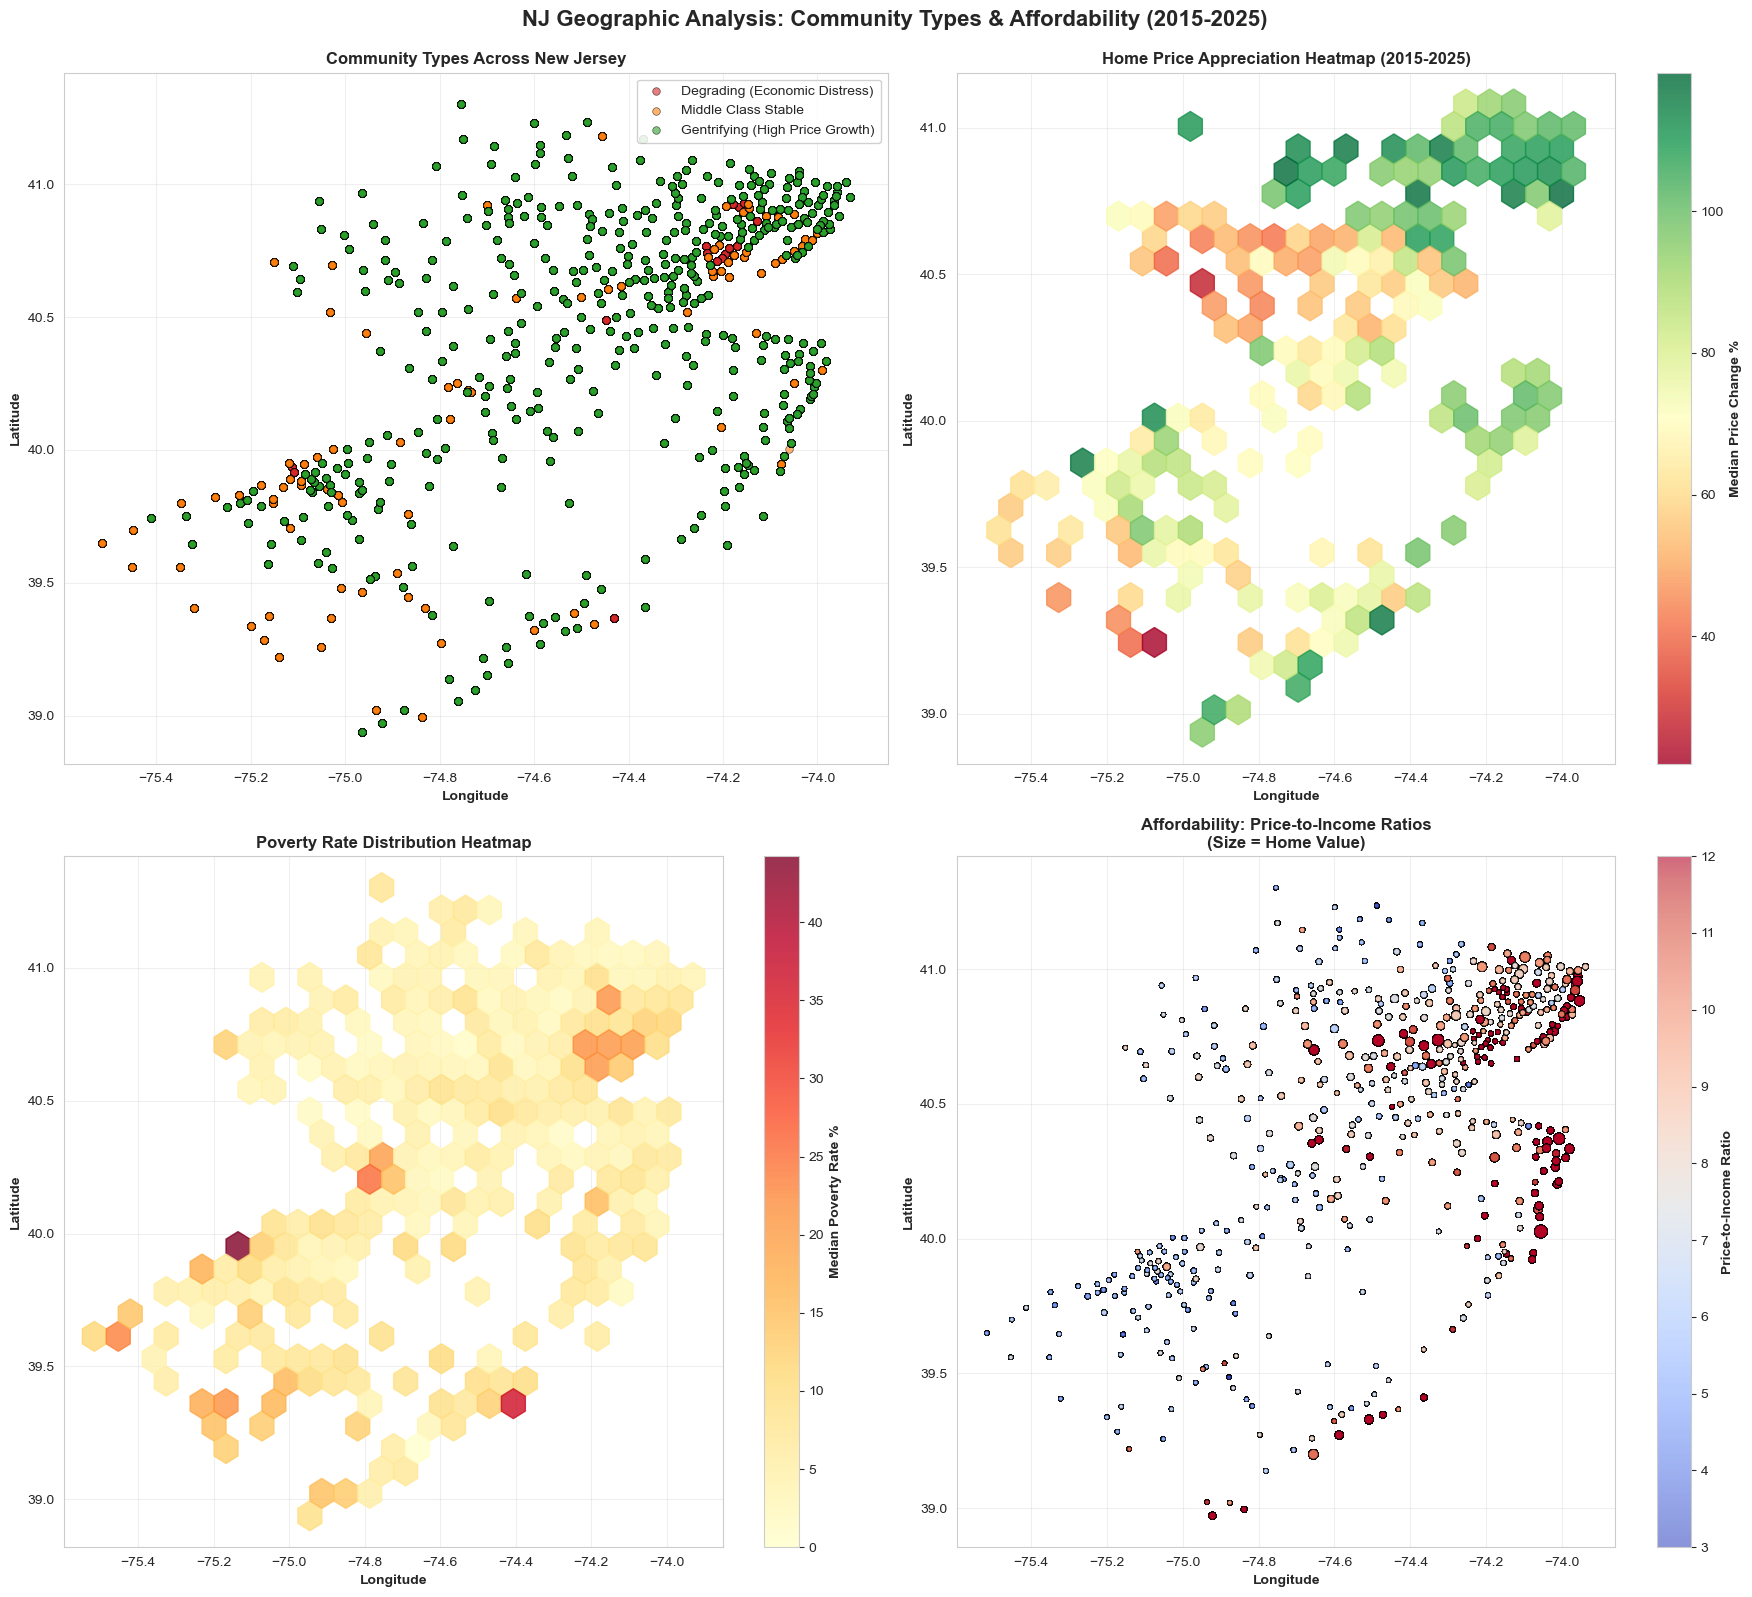


📊 Geographic visualization saved: nj_geographic_analysis_2015_2025.png


In [7]:
# Create geographic visualizations
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
fig.suptitle('NJ Geographic Analysis: Community Types & Affordability (2015-2025)', 
             fontsize=16, fontweight='bold', y=0.995)

# 1. Community Type Geographic Distribution (Scatterplot)
ax1 = axes[0, 0]
for comm_type, color in PALETTE.items():
    data = comparison_geo[comparison_geo['community_type'] == comm_type]
    ax1.scatter(data['lng'], data['lat'], 
               c=color, label=comm_type, 
               alpha=0.6, s=30, edgecolors='black', linewidth=0.5)

ax1.set_xlabel('Longitude', fontweight='bold')
ax1.set_ylabel('Latitude', fontweight='bold')
ax1.set_title('Community Types Across New Jersey', fontweight='bold', fontsize=12)
ax1.legend(loc='upper right', framealpha=0.9)
ax1.grid(True, alpha=0.3)

# 2. Price Change Heatmap (Hexbin)
ax2 = axes[0, 1]
# Cap extreme values for better visualization
price_data = comparison_geo[
    (comparison_geo['price_change_pct'] >= -20) & 
    (comparison_geo['price_change_pct'] <= 120)
].copy()

hexbin = ax2.hexbin(price_data['lng'], price_data['lat'], 
                    C=price_data['price_change_pct'],
                    gridsize=25, cmap='RdYlGn', 
                    reduce_C_function=np.median,
                    mincnt=1, alpha=0.8)
cb2 = plt.colorbar(hexbin, ax=ax2)
cb2.set_label('Median Price Change %', fontweight='bold')
ax2.set_xlabel('Longitude', fontweight='bold')
ax2.set_ylabel('Latitude', fontweight='bold')
ax2.set_title('Home Price Appreciation Heatmap (2015-2025)', fontweight='bold', fontsize=12)
ax2.grid(True, alpha=0.3)

# 3. Poverty Rate Heatmap
ax3 = axes[1, 0]
poverty_data = comparison_geo.dropna(subset=['poverty_rate'])

hexbin = ax3.hexbin(poverty_data['lng'], poverty_data['lat'],
                    C=poverty_data['poverty_rate'],
                    gridsize=25, cmap='YlOrRd',
                    reduce_C_function=np.median,
                    mincnt=1, alpha=0.8)
cb3 = plt.colorbar(hexbin, ax=ax3)
cb3.set_label('Median Poverty Rate %', fontweight='bold')
ax3.set_xlabel('Longitude', fontweight='bold')
ax3.set_ylabel('Latitude', fontweight='bold')
ax3.set_title('Poverty Rate Distribution Heatmap', fontweight='bold', fontsize=12)
ax3.grid(True, alpha=0.3)

# 4. Price-to-Income Ratio Scatterplot with Size
ax4 = axes[1, 1]
affordability_data = comparison_geo.dropna(subset=['price_to_income_ratio', 'current_home_value'])
# Cap extreme ratios
affordability_data = affordability_data[affordability_data['price_to_income_ratio'] <= 20]

# Size based on home value
sizes = (affordability_data['current_home_value'] / 50000).clip(10, 200)

scatter = ax4.scatter(affordability_data['lng'], affordability_data['lat'],
                     c=affordability_data['price_to_income_ratio'],
                     s=sizes, cmap='coolwarm', alpha=0.6,
                     edgecolors='black', linewidth=0.5,
                     vmin=3, vmax=12)
cb4 = plt.colorbar(scatter, ax=ax4)
cb4.set_label('Price-to-Income Ratio', fontweight='bold')
ax4.set_xlabel('Longitude', fontweight='bold')
ax4.set_ylabel('Latitude', fontweight='bold')
ax4.set_title('Affordability: Price-to-Income Ratios\n(Size = Home Value)', 
             fontweight='bold', fontsize=12)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
Path('visualizations').mkdir(exist_ok=True)
plt.savefig('visualizations/nj_geographic_analysis_2015_2025.png', dpi=300, bbox_inches='tight')
plt.show()
#print("\n📊 Geographic visualization saved: nj_geographic_analysis_2015_2025.png")

## 7. Statistical Visualizations

## 8. Export Results

## 9. Close Connection

## 7. Close Connection

In [8]:
# Close database connection
conn.close()
print("\n✅ Analysis complete. Database connection closed.")


✅ Analysis complete. Database connection closed.
